In [1]:
# Enable automatic reloading of modules before executing code
%load_ext autoreload
%autoreload 2

In [2]:
import os
import copy

from functools import partial, reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import seaborn as sns
import torch
import pingouin as pg
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

import matplotlib.colors as mcolors

from functools import partial
from multiprocessing import Pool, cpu_count
from tqdm.notebook import tqdm


In [3]:
import utils as ut

In [4]:
pd.set_option('display.max_columns', 100)

In [5]:
# test run of the model for dev purposes, or full/final data set?
is_testcase = False

# Load Model Results from Disk

In [6]:
l_data_subset = ["full"]
l_rnd_seed = [1]
l_embed_dim = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 25, 35]
modeltype = "free_weights_no_scaling"
modelversion = "embeddings-decision-combined-data"
l_id_weights = ["separate"]
l_lmbda = [1e-07]

# load results from model run
l_results_full = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda, l_id_weights_type=l_id_weights,
    l_embed_dim=l_embed_dim, modelversion=modelversion, modeltype=modeltype
)[0]

In [7]:
l_rnd_seed = [1, 2, 3]
l_embed_dim = [2, 3, 4, 5, 6]
l_data_subset = ["first_half", "second_half"]

# load results from model run
l_results_splithalf_lodim = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda, l_id_weights_type=l_id_weights,
    l_embed_dim=l_embed_dim, modelversion=modelversion, modeltype=modeltype
)[0]

l_rnd_seed = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
l_embed_dim = [7, 8, 9]

l_results_splithalf_meddim = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda, l_id_weights_type=l_id_weights,
    l_embed_dim=l_embed_dim, modelversion=modelversion, modeltype=modeltype
)[0]

l_rnd_seed = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
l_embed_dim = [10, 15]

l_results_splithalf_hidim = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda, l_id_weights_type=l_id_weights,
    l_embed_dim=l_embed_dim, modelversion=modelversion, modeltype=modeltype
)[0]

l_rnd_seed = [1]
l_embed_dim = [25, 35]
l_results_splithalf_veryhidim = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda, l_id_weights_type=l_id_weights,
    l_embed_dim=l_embed_dim, modelversion=modelversion, modeltype=modeltype
)[0]

no results found in ./results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/7d/lmbda_1e-07/separate/seed10/data_subset_first_half
no results found in ./results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/7d/lmbda_1e-07/separate/seed10/data_subset_second_half
no results found in ./results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/7d/lmbda_1e-07/separate/seed11/data_subset_first_half
no results found in ./results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/7d/lmbda_1e-07/separate/seed11/data_subset_second_half


In [8]:
l_results_splithalf = l_results_splithalf_lodim + l_results_splithalf_meddim + l_results_splithalf_hidim + l_results_splithalf_veryhidim

In [9]:
partial_sims = partial(ut.dimensional_similarities, l_results_splithalf)
range_dims = [i for i in range(2, 11)] + [15, 25, 35]
l_cors = list(map(partial_sims, range_dims))

In [10]:
# reorder dimensions in the two halves according to the max. similar result
partial_reorder = partial(ut.reorder_dimensions, l_results_splithalf)
l_max_sims = list(map(partial_reorder, range_dims))
dict_max_sims = dict(zip(range_dims, l_max_sims))

In [11]:
# extract idxs from seeds with maximally similar embedding dimensions
dict_idxs_use = ut.max_sim_dimensions_per_ndim(l_max_sims, range_dims)
dict_idxs_list_use = ut.max_sim_results_per_ndim(dict_idxs_use, dict_max_sims, range_dims)

In [12]:
for n_embed in [15, 25, 35]:
    dict_idxs_list_use[n_embed] = [idx for idx, l in enumerate(l_results_splithalf) if l["n_embed"] == n_embed][0:2]

In [13]:
l_keys = list(dict_idxs_use.keys())
dict_cors = {int(f'{l_keys[i]}'): sublist for i, sublist in enumerate(l_cors)}

In [14]:
# Load Relevant IDs for correlational analyses
if is_testcase:
    df_pids = pd.read_csv("data/study1-2025-08/new-participant-ids-in-joint-modeling-testcase.csv")
elif not is_testcase:
    df_pids = pd.read_csv("data/study1-2025-08/new-participant-ids-in-joint-modeling.csv")

In [15]:
df_things_participants = ut.load_things_participants()

In [16]:
# get participant ids from the new data
l_pids_model = list(df_pids["participant_id_model"])
l_pids_new = list(df_pids["participant_id_new"])

# get participant ids from the THINGS data
l_pids_model_THINGS = df_things_participants["participant_id_model"].tolist()
l_pids_model_THINGS_new = df_things_participants["pid"].tolist()

In [17]:
l_n_embed_full = [l["n_embed"] for l in l_results_full]

In [18]:
# Define the function with all arguments
def correlations_wrapper(dim, l_results_full, l_results_splithalf, is_testcase):
    return ut.correlations_with_summary_stats(
        dim,
        l_results_full=l_results_full,
        l_results_splithalf=l_results_splithalf,
        is_testcase=is_testcase,
        range_dims = range_dims
    )

# Prepare arguments
args = [(dim, l_results_full, l_results_splithalf, is_testcase) for dim in range_dims]

def unpack_and_run(arg):
    return correlations_wrapper(*arg)

with Pool(cpu_count()) as pool:
    l_df_overview = list(tqdm(
        pool.imap_unordered(unpack_and_run, args),
        total=len(args)
    ))


  0%|          | 0/12 [00:00<?, ?it/s]

In [19]:
df_overview = reduce(lambda x, y: pd.concat([x, y]), l_df_overview)
rename_dict1 = {
    "motivation_1": "Motivation (Self Report)",
    "edu": "Years Education",
    "Sex_0": "Gender (1: Women)",
    "age": "Age",
    "Open_Mindedness": "Open Mindedness",
    "rt": "RT / Triplet",
    "income_0": "Income",
    "Negative_Emotionality": "Negative Emotionality"
}
rename_dict2 = {
    "weights_delta_abs_sum": "Absolute Delta",
    "gini_overall": "Gini Coefficient",
    "avg_weight": "Average Weight"
}

# Apply renaming
df_overview["var"] = df_overview["var"].replace(rename_dict1)
df_overview["var_fixed"] = df_overview["var_fixed"].replace(rename_dict2)

df_overview.columns = ["Variable", "r", "pval", "Summary Stat", "Nr. Embed"]
df_overview["below_thx"] = df_overview["pval"] <= 0.05

In [21]:
vars_interested = [i for i in list(df_overview.Variable.unique()) if i != "idx"]

In [23]:
df_plt = df_overview.query(f"Variable in {vars_interested}")#  and `Nr. Embed` == 35
df_order = df_plt.groupby(["Variable", "Summary Stat"])["r"].mean().reset_index().sort_values(["Summary Stat", "r"], ascending=False)
df_plt = df_order.merge(df_plt, how="left", on=["Variable", "Summary Stat"], suffixes=["_avg", "_actual"])

In [30]:
df_plt["Summary Stat"] = pd.Categorical(
    df_plt["Summary Stat"].astype(str),
    categories=[f"{x}" for x in ordered_sumstat],
    ordered=True
)

/tmp/ipykernel_2944324/1522778038.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(wrapped_labels)
/tmp/ipykernel_2944324/1522778038.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(wrapped_labels)
/tmp/ipykernel_2944324/1522778038.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(wrapped_labels)


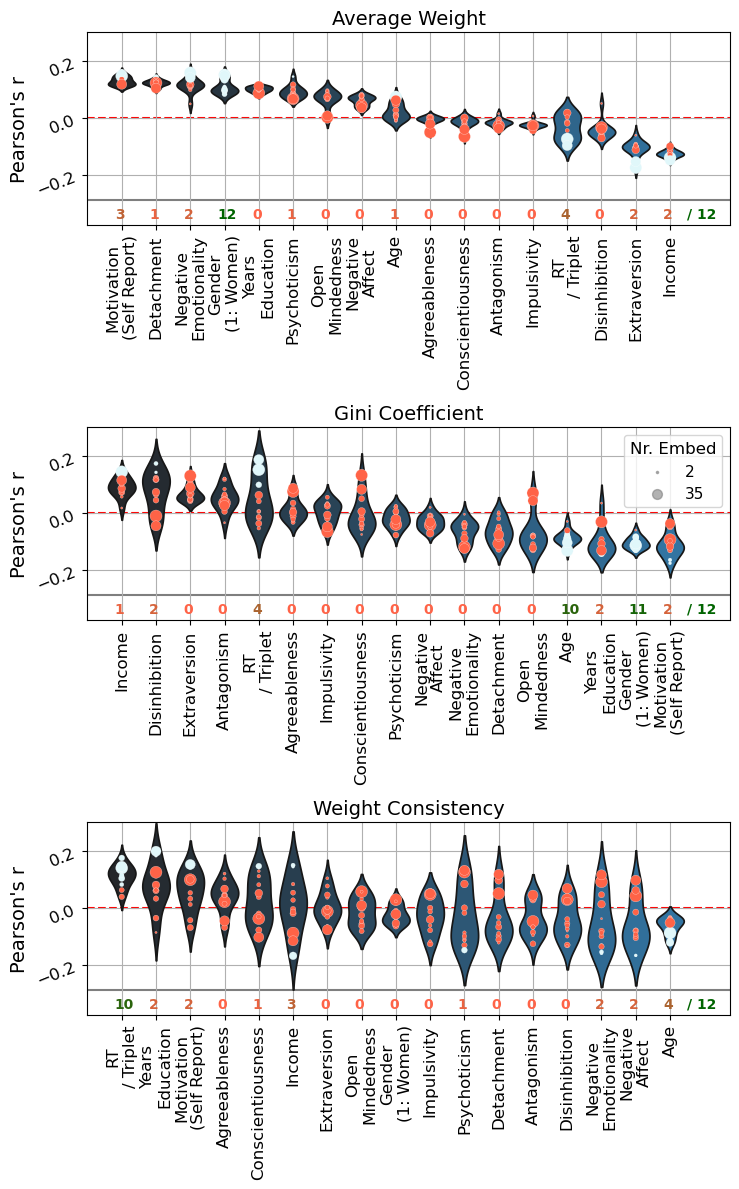

In [37]:
df_plt = df_overview.query(f"Variable in {vars_interested}")#  and `Nr. Embed` == 35
df_order = df_plt.groupby(["Variable", "Summary Stat"])["r"].mean().reset_index().sort_values(["Summary Stat", "r"], ascending=False)
df_plt = df_order.merge(df_plt, how="left", on=["Variable", "Summary Stat"], suffixes=["_avg", "_actual"])
ordered_sumstat = ["Average Weight", "Gini Coefficient", "Absolute Delta"]
df_plt["Summary Stat"] = pd.Categorical(
    df_plt["Summary Stat"].astype(str),
    categories=[f"{x}" for x in ordered_sumstat],
    ordered=True
)
palette = {
    False: "tomato",
    True: "#E0F7FA"
}

f, axes = plt.subplots(3, figsize=(7.5, 12))

# Get min and max values for "Nr. Embed"
min_embed = df_plt["Nr. Embed"].min()
max_embed = df_plt["Nr. Embed"].max()

# Define a colormap from tomato (red) to darkgreen
cmap = mcolors.LinearSegmentedColormap.from_list("tomato_green", ["tomato", "darkgreen"])

# Normalize values between 0 and 12
norm = mcolors.Normalize(vmin=0, vmax=12)

for i, sumstat in enumerate(list(df_plt["Summary Stat"].cat.categories)):
    # select relevant summary stat
    df_plt_current = df_plt.query(f"`Summary Stat` == '{sumstat}'").copy()
    # count the nr of significant results per var
    df_count_sig = df_plt_current.groupby(["Variable", "r_avg"]).agg({"below_thx": ["sum", "count"]}).reset_index()
    df_count_sig.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df_count_sig.columns.values]
    df_count_sig.columns = [col.strip("_") for col in df_count_sig.columns]
    df_count_sig.sort_values("r_avg", ascending=False, inplace=True)

    sns.violinplot(
        data=df_plt_current, x="Variable", y="r_actual", hue="Variable", 
        inner=None, zorder=2, palette='dark:#1f77b4', ax=axes[i]
    )
    sns.scatterplot(
        data=df_plt_current, x="Variable", y="r_actual", hue="below_thx", size="Nr. Embed", alpha=1, zorder=2, 
        palette=palette, sizes=(2.5, 75), legend=False, ax=axes[i]
    )
        # After drawing your plot
    cats = [tick.get_text() for tick in axes[i].get_xticklabels()]
    xs   = axes[i].get_xticks()
    xmap = dict(zip(cats, xs))
    # Use numeric x from the mapping, then nudge
   
    
    for _, row in df_count_sig.iterrows():
        x = xmap[row["Variable"]] - 0.2
        axes[i].text(x, -.35, str(row["below_thx_sum"]),
                     fontsize=10, fontweight="bold", color=cmap(norm(row["below_thx_sum"])))
    
    axes[i].set_ylabel("Pearson's r", fontsize=14)
    axes[i].set_xlabel("", fontsize=12)
    axes[i].axhline(y=0, color="red", linestyle="--", zorder=1)

    # Get current tick labels
    labels = [tick.get_text() for tick in axes[i].get_xticklabels()]
    # Wrap each label onto two rows (insert newline)
    wrapped_labels = [label.replace(" ", "\n", 1) for label in labels]
    axes[i].set_xticklabels(wrapped_labels)
    
    axes[i].tick_params(axis="x", rotation=90, labelsize=12)
    axes[i].tick_params(axis="y", labelsize=12, rotation=22)
    axes[i].set_title(sumstat, fontsize=14)
    axes[i].grid(True)
    axes[i].set_ylim((-.375, .3))
    axes[i].set_xlim(-1, df_plt_current["Variable"].nunique() + .75)
    axes[i].axhline(y=-.29, color="black", alpha=.5, zorder=1)

    

    x2 = xmap[row["Variable"]] + .5
    # Example usage inside your loop
    axes[i].text(
        x2, -.35, "/ " + str(row["below_thx_count"]),
        fontsize=10,
        fontweight="bold",
        color= cmap(norm(row["below_thx_count"])) # mapped color
    )


# Add the size legend to the last axis (or choose one)
# Create dummy scatter handles with corresponding sizes
min_handle = plt.scatter([], [], s=2.5, label=f"{min_embed}", color="gray", alpha=0.6)
max_handle = plt.scatter([], [], s=50, label=f"{max_embed}", color="gray", alpha=0.6)

axes[2].set_title("Weight Consistency", fontsize=14)
axes[1].legend(
    handles=[min_handle, max_handle],
    title="Nr. Embed",
    loc="upper right",
    bbox_to_anchor=(1, 1),  # Adjust position as needed
    frameon=True,
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout()
f.savefig("documents/writeup/figures-plotting/qs-dems-correlations.pdf")